# HelpSteer2 Dataset Distribution Analysis
Bucket breakdown (easy / medium / hard / tie) for train and validation splits.

In [1]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DATA_DIR = Path("../data")
BUCKETS   = ["easy", "medium", "hard", "tie"]
SPLITS    = ["train", "validation"]
COLORS    = {"easy": "#4CAF50", "medium": "#2196F3", "hard": "#FF9800", "tie": "#9E9E9E"}

In [2]:
frames = {}
for split in SPLITS:
    path = DATA_DIR / f"helpsteer2_{split}_full.json"
    with open(path) as f:
        data = json.load(f)
    frames[split] = pd.DataFrame(data)
    print(f"{split:12s}: {len(data):,} pairs")

train       : 10,166 pairs
validation  : 519 pairs


## Pair counts per bucket

In [3]:
counts = {}
for split, df in frames.items():
    c = df["difficulty"].value_counts().reindex(BUCKETS, fill_value=0)
    counts[split] = c

summary = pd.DataFrame(counts).rename_axis("bucket")
summary["train_%"]      = (summary["train"]      / summary["train"].sum()      * 100).round(1)
summary["validation_%"] = (summary["validation"] / summary["validation"].sum() * 100).round(1)
summary

,train,validation,train_%,validation_%
bucket,,,,
easy,2672,130,26.3,25.0
medium,2071,112,20.4,21.6
hard,3286,171,32.3,32.9
tie,2137,106,21.0,20.4


## Bar charts — absolute counts

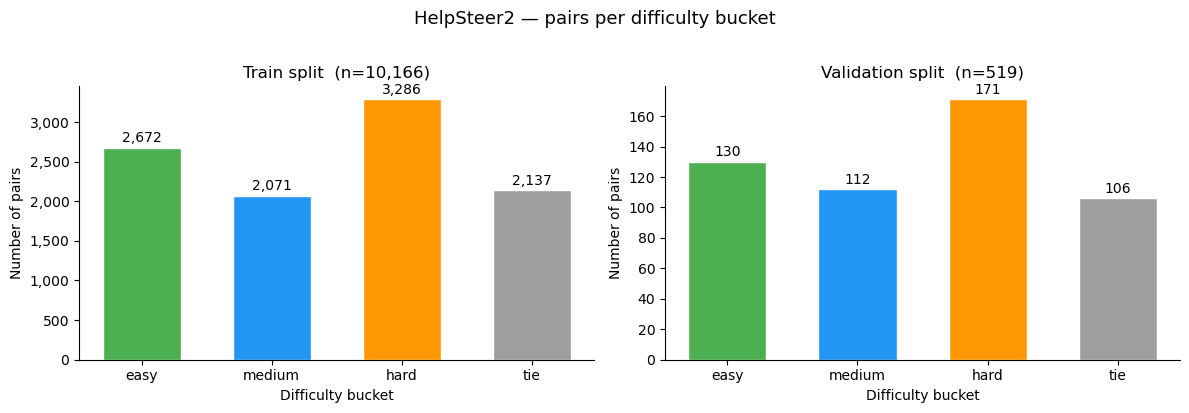

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, split in zip(axes, SPLITS):
    c = counts[split]
    bars = ax.bar(BUCKETS, c.values, color=[COLORS[b] for b in BUCKETS], edgecolor="white", width=0.6)
    for bar, v in zip(bars, c.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + c.max() * 0.01,
                f"{v:,}", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"{split.capitalize()} split  (n={c.sum():,})", fontsize=12)
    ax.set_xlabel("Difficulty bucket")
    ax.set_ylabel("Number of pairs")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("HelpSteer2 — pairs per difficulty bucket", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Stacked percentage chart — both splits side-by-side

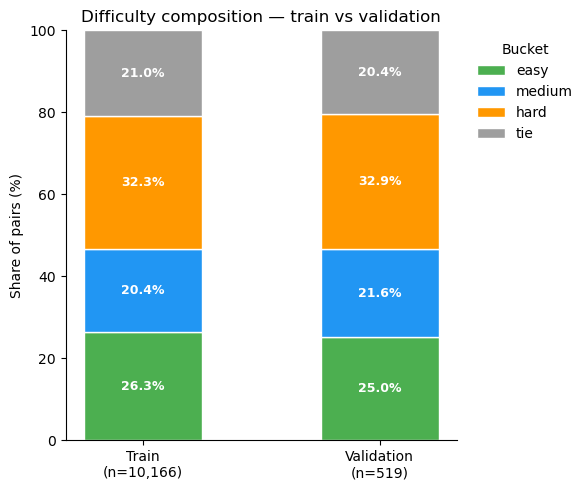

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

x = np.arange(len(SPLITS))
bottoms = np.zeros(len(SPLITS))

pcts = {split: counts[split] / counts[split].sum() * 100 for split in SPLITS}

for bucket in BUCKETS:
    vals = [pcts[split][bucket] for split in SPLITS]
    bars = ax.bar(x, vals, bottom=bottoms, label=bucket, color=COLORS[bucket], edgecolor="white", width=0.5)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 2:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottoms[i] + v / 2,
                    f"{v:.1f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    bottoms += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([f"{s.capitalize()}\n(n={counts[s].sum():,})" for s in SPLITS])
ax.set_ylabel("Share of pairs (%)")
ax.set_ylim(0, 100)
ax.set_title("Difficulty composition — train vs validation", fontsize=12)
ax.legend(title="Bucket", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Score-gap distribution per bucket

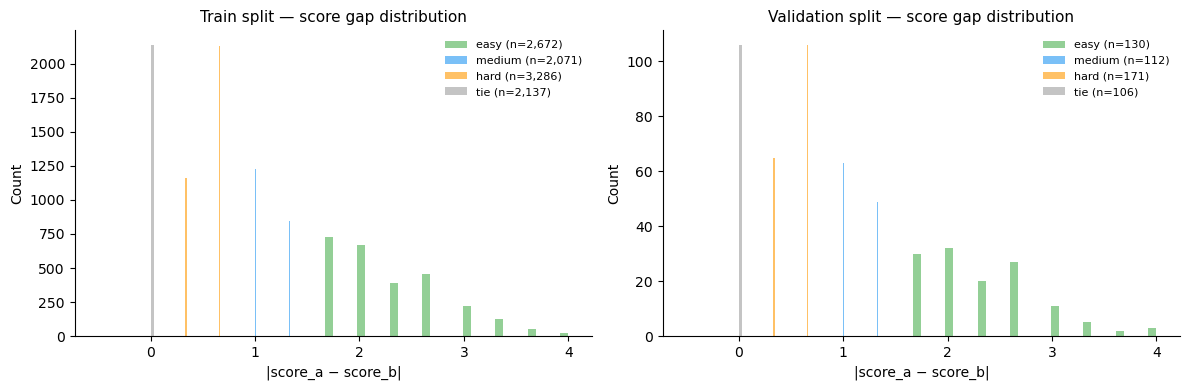

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, split in zip(axes, SPLITS):
    df = frames[split]
    for bucket in BUCKETS:
        sub = df[df["difficulty"] == bucket]["score_gap"].dropna()
        if sub.empty:
            continue
        ax.hist(sub, bins=30, alpha=0.6, label=f"{bucket} (n={len(sub):,})",
                color=COLORS[bucket], edgecolor="none")
    ax.set_title(f"{split.capitalize()} split — score gap distribution", fontsize=11)
    ax.set_xlabel("|score_a − score_b|")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## Gold-label breakdown per bucket

In [7]:
for split, df in frames.items():
    print(f"\n=== {split} ===")
    tbl = (
        df.groupby(["difficulty", "gold_label"])
          .size()
          .unstack(fill_value=0)
          .reindex(BUCKETS)
    )
    tbl["total"] = tbl.sum(axis=1)
    for lbl in ["A", "B", "C"]:
        if lbl in tbl.columns:
            tbl[f"{lbl}%"] = (tbl[lbl] / tbl["total"] * 100).round(1)
    print(tbl.to_string())


=== train ===
gold_label     A     B     C  total    A%    B%     C%
difficulty                                            
easy        1333  1339     0   2672  49.9  50.1    0.0
medium      1033  1038     0   2071  49.9  50.1    0.0
hard        1656  1630     0   3286  50.4  49.6    0.0
tie            0     0  2137   2137   0.0   0.0  100.0

=== validation ===
gold_label   A   B    C  total    A%    B%     C%
difficulty                                       
easy        68  62    0    130  52.3  47.7    0.0
medium      59  53    0    112  52.7  47.3    0.0
hard        83  88    0    171  48.5  51.5    0.0
tie          0   0  106    106   0.0   0.0  100.0
